# About

This notebook builds the example for matrix multiplications in the book.

## Note on Matrix Transpose

We will see `.T` (transpose) frequently because `brushcue` internally uses a column-major representation for matrices when applying transformations, while `numpy`'s default matrix multiplication (`@`) assumes a row-major interpretation for vectors. This transpose ensures consistency between `numpy`'s calculations and `brushcue`'s image processing.

In [20]:
import os
from pathlib import Path
from urllib.request import urlretrieve

import brushcue as bc
import numpy as np

TEST_IMAGE_NAME = 'a-sunday-on-la-grande-jatte.jpg'
TEST_IMAGE_URL = f'https://www.brushcue.com/book/images/{TEST_IMAGE_NAME}'
LOCAL_TEST_IMAGE_PATH = next((
    parent / 'js' / 'monet' / 'public' / 'book' / 'images' / TEST_IMAGE_NAME
    for parent in (Path.cwd(), *Path.cwd().parents)
    if (parent / 'js' / 'monet' / 'public' / 'book' / 'images' / TEST_IMAGE_NAME).exists()
), None)
ctx = bc.Context()
EXAMPLE_COLOR = np.array([(162/255), (167/255), (101/255), 1]).T # this color needs work, probably should extract from the picture itself at a given point.

def matrix_for_step(step: int) -> np.array:
  if step == 1:
    return np.array([
        [1.0, 0.0, 0.0, 0.0],
        [0.0, 1.0, 0.0, 0.0],
        [0.0, 0.0, 0.7, 0.0],
        [0.0, 0.0, 0.0, 1.0]
    ]).T
  elif step == 2:
    return np.array([
        [0.7, 0.15, 0.15, 0.0],
        [0.15, 0.7, 0.15, 0.0],
        [0.15, 0.15, 0.7, 0.0],
        [0.0, 0.0, 0.0, 1.0]
    ]).T
  elif step == 3:
      return np.array([
        [1.5, 0.0, 0.0, 0.0],
        [0.0, 1.5, 0.0, 0.0],
        [0.0, 0.0, 1.5, 0.0],
        [0.0, 0.0, 0.0, 1.0]
    ]).T
  elif step == 4:
    return np.array([
        [0.0, 1.0, 0.0, 0.0],
        [0.0, 0.0, 1.0, 0.0],
        [1.0, 0.0, 0.0, 0.0],
        [0.0, 0.0, 0.0, 1.0]
    ]).T
  else:
    raise ValueError("Matrix not defined at step", step)

def download_test_image() -> str:
  temp_dir = '/tmp'
  os.makedirs(temp_dir, exist_ok=True)
  if LOCAL_TEST_IMAGE_PATH is not None:
    return str(LOCAL_TEST_IMAGE_PATH)
  temp_file_path = os.path.join(temp_dir, TEST_IMAGE_NAME)

  if os.path.exists(temp_file_path):
    return temp_file_path
  else:
    urlretrieve(TEST_IMAGE_URL, temp_file_path)
    return temp_file_path

def path_for_end_of_step_image(step_number):
  if step_number == 0:
    return download_test_image()
  return f'/tmp/step_{step_number}.png'

def path_for_color_image(step_number):
  return f'/tmp/color_{step_number}.png'

def apply_matrix_to_image(image_path: str, matrix: np.array, output_path: str):
  image = bc.load_composition(image_path)
  image = bc.composition_linear_transform(
      image,
      matrix[0, 0], matrix[0, 1], matrix[0, 2], matrix[0, 3],
      matrix[1, 0], matrix[1, 1], matrix[1, 2], matrix[1, 3],
      matrix[2, 0], matrix[2, 1], matrix[2, 2], matrix[2, 3],
      matrix[3, 0], matrix[3, 1], matrix[3, 2], matrix[3, 3]
  )
  result = image.execute(ctx)
  output_bytes = result.as_composition().to_image_bytes(ctx)
  with open(output_path, "wb") as f:
      f.write(bytes(output_bytes))

def color_at_end_of_step(step: int) -> np.array:
  if step == 0:
    return EXAMPLE_COLOR
  previous_color = color_at_end_of_step(step - 1)
  return matrix_for_step(step).T @ previous_color


def make_color_rect_image(step: int) -> str:
  color = color_at_end_of_step(step)
  color = bc.profiled_color_from_rgba_srgb(
      bc.r_g_b_a_color_constant(color[0], color[1], color[2], color[3])
  )
  painter = bc.painter_new()
  painter = bc.painter_add_rectangle_with_render_style(
      painter,
      bc.point2f_from_components(0, 0),
      bc.vector2f_constant(300, 300),
      0,
      bc.render_style_fill_only(bc.fill_solid(color)),
      bc.transform2_to_list(bc.transform2_identity()),
  )
  color_rect = bc.composition_painter(painter)
  result = color_rect.execute(ctx)
  output_path = path_for_color_image(step)
  output_bytes = result.as_composition().to_image_bytes(ctx)
  with open(output_path, "wb") as f:
      f.write(bytes(output_bytes))
  return output_path

def image_at_end_of_step(step: int) -> str:
  output_file_path = path_for_end_of_step_image(step)
  if os.path.exists(output_file_path):
    return output_file_path
  previous_image = image_at_end_of_step(step - 1)
  apply_matrix_to_image(previous_image, matrix_for_step(step), output_file_path)
  return output_file_path

In [21]:
from IPython.display import Image, Markdown, display
from PIL import Image as PILImage
import io

def display_scaled(path: str, width: int = 500):
  with PILImage.open(path) as img:
    h = int(img.height * width / img.width)
    resized = img.resize((width, h), PILImage.LANCZOS)
    buf = io.BytesIO()
    resized.save(buf, format="PNG", optimize=True)
    display(Image(data=buf.getvalue(), width=width))

def display_step(step: int):
  display(Markdown(f"### Step {step}"))
  # Print the matrix once at the top for each step
  display(Markdown("#### Transformation Matrix"))
  print(matrix_for_step(step).T)

  # Before state
  image_path_before = image_at_end_of_step(step - 1)
  color_values_before = color_at_end_of_step(step - 1)
  color_path_before = make_color_rect_image(step - 1)
  display(Markdown("#### Before Transformation"))
  display_scaled(image_path_before, width=500)
  print(f"Image path before: {image_path_before}")
  display_scaled(color_path_before, width=500)
  print(f"Color RGB values before: {color_values_before}")

  # After state
  image_path_after = image_at_end_of_step(step)
  color_values_after = color_at_end_of_step(step)
  color_path_after = make_color_rect_image(step)
  display(Markdown("#### After Transformation"))
  display_scaled(image_path_after, width=500)
  print(f"Image path after: {image_path_after}")
  display_scaled(color_path_after, width=500)
  print(f"Color RGB values after: {color_values_after}")


### Step 1

#### Transformation Matrix

[[1.  0.  0.  0. ]
 [0.  1.  0.  0. ]
 [0.  0.  0.7 0. ]
 [0.  0.  0.  1. ]]


#### Before Transformation

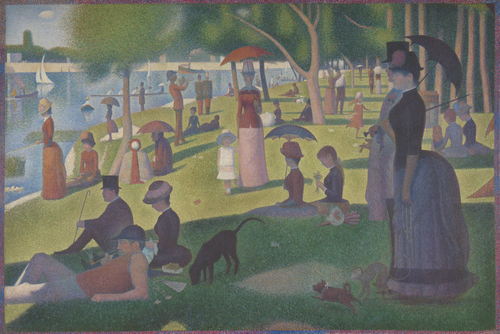

Image path before: /tmp/a-sunday-on-la-grande-jatte.jpg


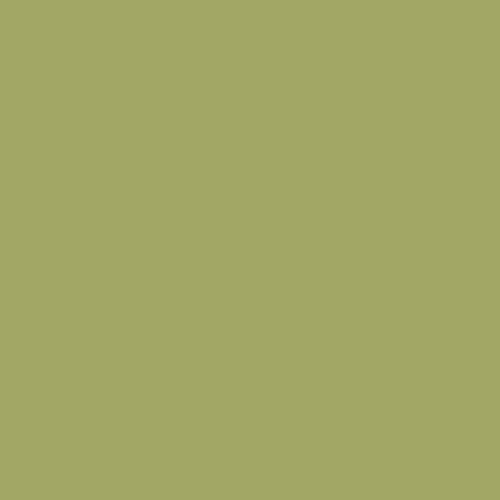

Color RGB values before: [0.63529412 0.65490196 0.39607843 1.        ]


#### After Transformation

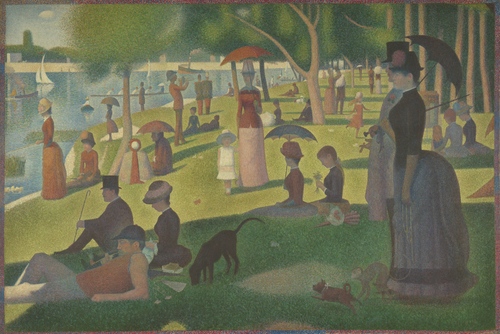

Image path after: /tmp/step_1.png


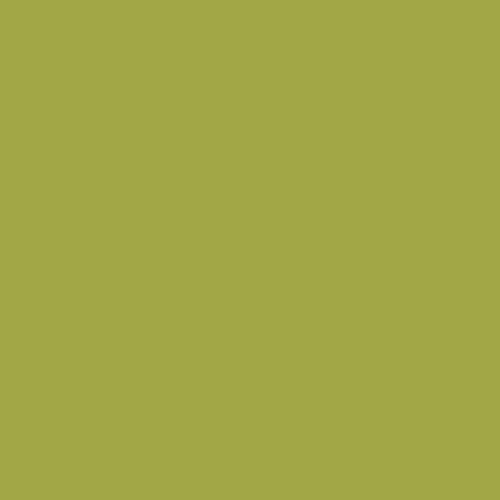

Color RGB values after: [0.63529412 0.65490196 0.2772549  1.        ]


In [22]:
display_step(1)

### Step 2

#### Transformation Matrix

[[0.7  0.15 0.15 0.  ]
 [0.15 0.7  0.15 0.  ]
 [0.15 0.15 0.7  0.  ]
 [0.   0.   0.   1.  ]]
[image_recipe::TextureCache] reusing tiled texture requested_hash=952501458716392912 cache_key=952501458716392912


#### Before Transformation

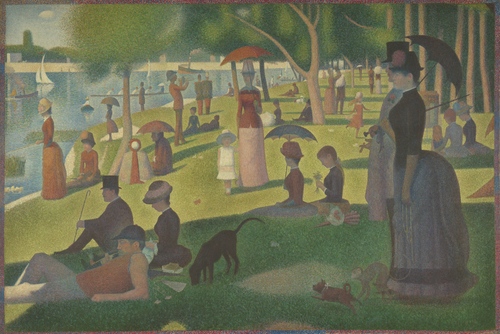

Image path before: /tmp/step_1.png


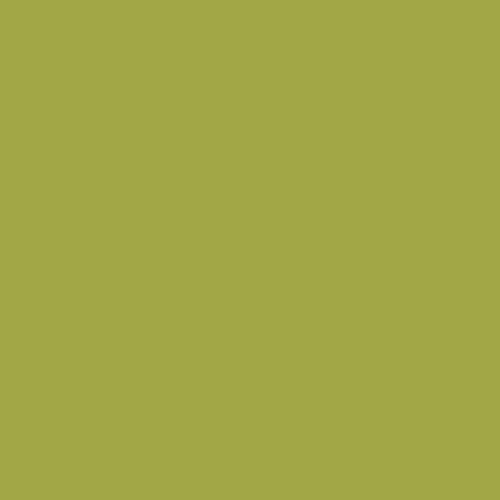

Color RGB values before: [0.63529412 0.65490196 0.2772549  1.        ]


#### After Transformation

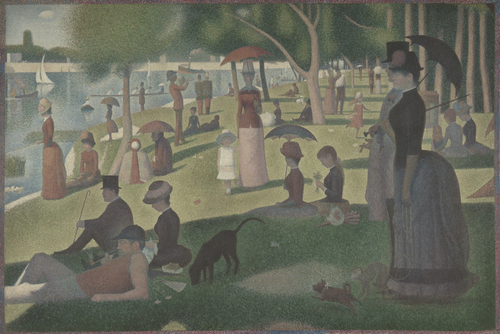

Image path after: /tmp/step_2.png


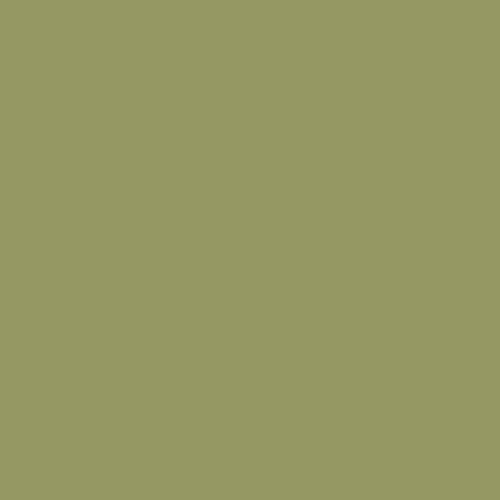

Color RGB values after: [0.58452941 0.59531373 0.38760784 1.        ]


In [23]:
display_step(2)

### Step 3

#### Transformation Matrix

[[1.5 0.  0.  0. ]
 [0.  1.5 0.  0. ]
 [0.  0.  1.5 0. ]
 [0.  0.  0.  1. ]]
[image_recipe::TextureCache] reusing tiled texture requested_hash=14315100108546816044 cache_key=14315100108546816044


#### Before Transformation

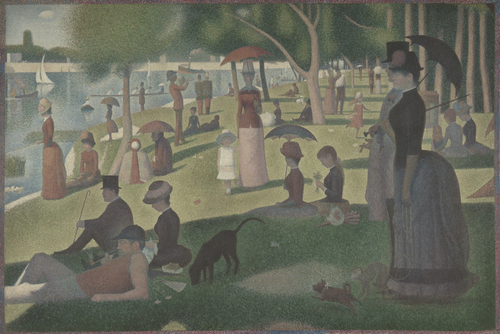

Image path before: /tmp/step_2.png


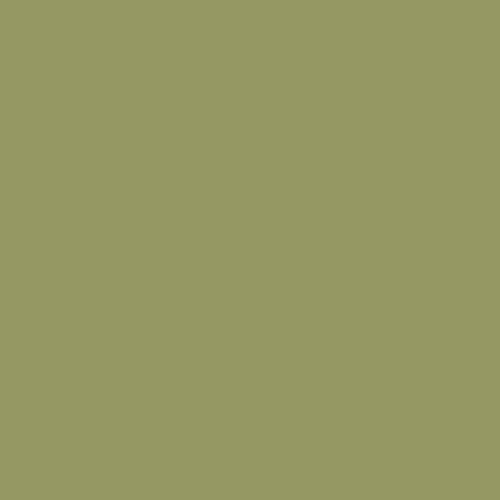

Color RGB values before: [0.58452941 0.59531373 0.38760784 1.        ]


#### After Transformation

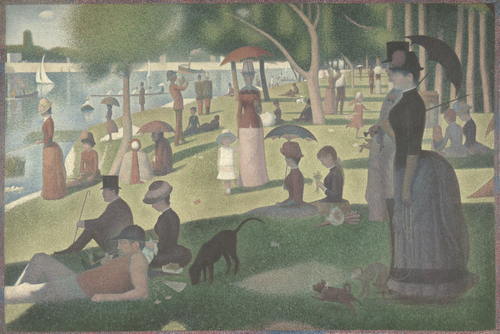

Image path after: /tmp/step_3.png


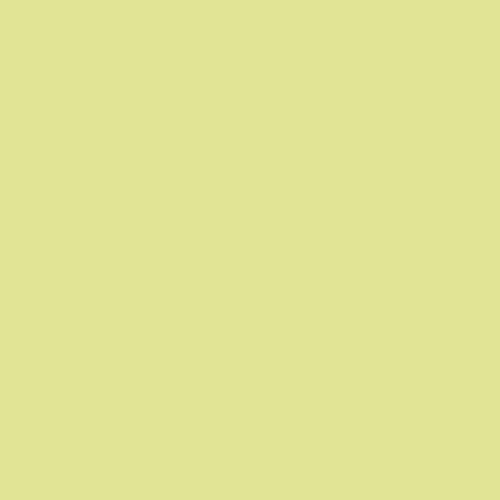

Color RGB values after: [0.87679412 0.89297059 0.58141176 1.        ]


In [24]:
display_step(3)

### Step 4

#### Transformation Matrix

[[0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [1. 0. 0. 0.]
 [0. 0. 0. 1.]]
[image_recipe::TextureCache] reusing tiled texture requested_hash=10901882859637130592 cache_key=10901882859637130592


#### Before Transformation

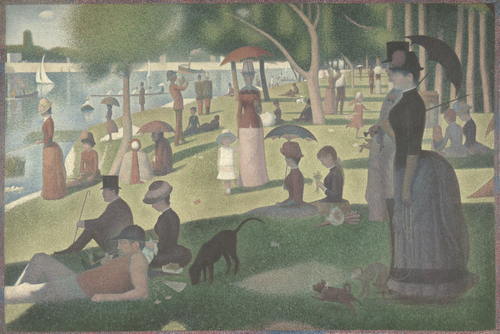

Image path before: /tmp/step_3.png


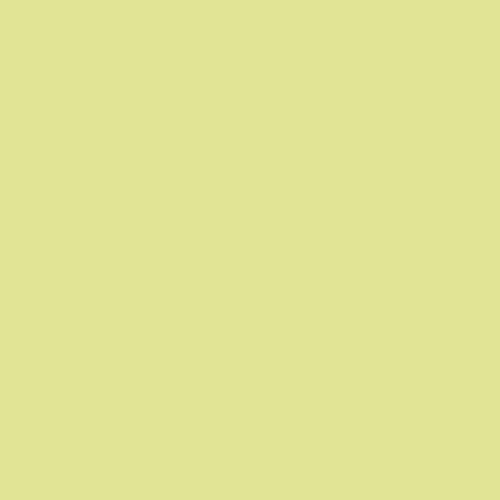

Color RGB values before: [0.87679412 0.89297059 0.58141176 1.        ]


#### After Transformation

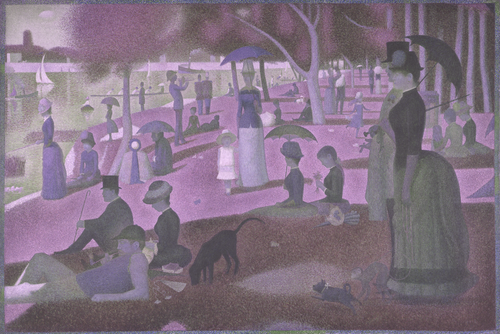

Image path after: /tmp/step_4.png


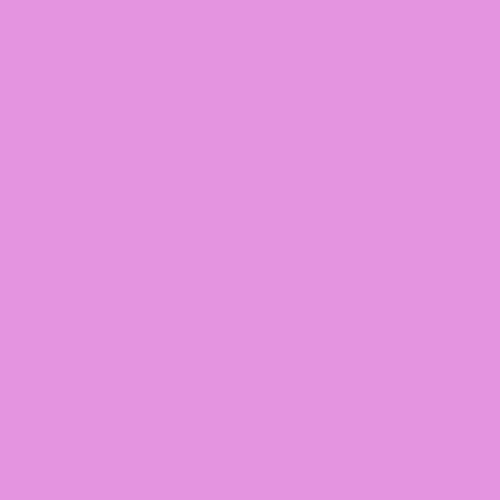

Color RGB values after: [0.89297059 0.58141176 0.87679412 1.        ]


In [25]:
display_step(4)

In [26]:
full_transform = matrix_for_step(4).T @ matrix_for_step(3).T @ matrix_for_step(2).T @ matrix_for_step(1).T
full_transform

array([[0.225 , 1.05  , 0.1575, 0.    ],
       [0.225 , 0.225 , 0.735 , 0.    ],
       [1.05  , 0.225 , 0.1575, 0.    ],
       [0.    , 0.    , 0.    , 1.    ]])

In [27]:
full_transform @ EXAMPLE_COLOR

array([0.89297059, 0.58141176, 0.87679412, 1.        ])

### Final Transformation

new pipeline: color_transformer_shader_rgba16float_compute_74330651998959330_inarr_false


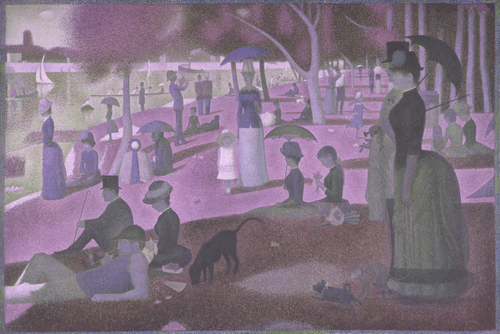

Final transformed image saved to: /tmp/final_transformed_image.png


In [28]:
final_image_path = '/tmp/final_transformed_image.png'
initial_image_path = path_for_end_of_step_image(0)
apply_matrix_to_image(initial_image_path, full_transform.T, final_image_path)
display_scaled(final_image_path, width=500)
print(f"Final transformed image saved to: {final_image_path}")